In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import shutil
import math 

from torchvision import datasets, transforms
# from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix, classification_report
from math import pi as PI
from scipy.special import gamma, kv
from time import perf_counter
from reml import NadarayaWatsonClassifier

rng = np.random.default_rng() 

import matplotlib_inline
matplotlib_inline.backend_inline.set_matplotlib_formats('retina')

plt.style.use('seaborn-v0_8-paper')
plt.rcParams.update(
    {
        'text.usetex': True
    }
)

In [2]:
# NOTE: AISTATS paper dimensions 
page_width_pt = 487.8225 
column_width_pt = 234.8775

def set_figure_size(width_pt, fraction=0.9, subplots=(1, 1), ratio=(5**0.5 - 1) / 2):
    fig_width_pt = width_pt * fraction
    inches_per_pt = 1 / 72.27

    fig_width_in = fig_width_pt * inches_per_pt
    fig_height_in = fig_width_in * ratio * (subplots[0] / subplots[1])

    return (fig_width_in, fig_height_in)

base_figure_size = set_figure_size(page_width_pt, 0.9, (1, 1))

In [ ]:
num_train = 60000
num_test = 10 # minimum 10
# bandwidth = 7.47
bandwidth = 3.

rbf_kernel_hyperparameters = {'s': 1.}

In [4]:
# Delete and redownload the MNIST dataset
# shutil.rmtree('./data', ignore_errors=True)
train_set = datasets.MNIST('./data', train=True, download=True)
test_set = datasets.MNIST('./data', train=False, download=True)

def load_train_set(n_train):
    num_train = n_train

    # Process training data
    train_set_array = train_set.data.numpy()
    x_train = train_set_array.reshape(train_set_array.shape[0], -1)[:num_train]
    x_train = x_train / 255.0  # Normalize to [0, 1]

    # Process training labels
    y_train = train_set.targets.numpy()[:num_train]

    # Create one-hot encoded labels for multi-class classification
    y_train_one_hot = np.zeros((num_train, 10))
    for i in range(num_train):
        y_train_one_hot[i, y_train[i]] = 1

    res = {'x_train': x_train, 'y_train': y_train, 'y_train_one_hot': y_train_one_hot}
    return res

def load_test_set(n_test):
    # Process test data - just take a few examples for demonstration
    test_set_array = test_set.data.numpy()
    y_test_all = test_set.targets.numpy()
    test_indices = []

    # First, ensure we have at least one of each digit (0-9)
    for digit in range(10):
        digit_indices = np.where(y_test_all == digit)[0]
        if len(digit_indices) > 0:
            # Select one random sample of this digit
            selected_idx = rng.choice(digit_indices, 1)[0]
            test_indices.append(selected_idx)

    # If we need additional samples to reach num_test
    remaining = n_test - len(test_indices)
    if remaining > 0:
        remaining_indices = np.setdiff1d(np.arange(len(y_test_all)), test_indices)
        additional_indices = rng.choice(remaining_indices, remaining, replace=False)
        test_indices.extend(additional_indices)

    test_indices = np.array(test_indices[:n_test])
    x_test = test_set_array[test_indices].reshape(n_test, -1)
    x_test = x_test / 255.0
    y_test = y_test_all[test_indices]

    res = {'x_test': x_test, 'y_test': y_test}
    return res

In [5]:
dataset = load_train_set(num_train)
validation = load_test_set(num_test)
x_train, y_train, y_train_one_hot = dataset.values()
x_test, y_test = validation.values()

In [6]:
"""
KERNEL FUNCTIONS
Here's where all the kernel functions are defined. If you want a new one, add them here. 
"""
def K_rbf(x, s):
    squared_exponential = s ** 2 * np.exp(-(x**2/2))    
    return np.minimum(squared_exponential, 1.)

def K_matern(x, s, v, l):
    if np.isscalar(x) and x == 0:
        x = 1e-8
    elif isinstance(x, np.ndarray):
        x = x.copy()
        x[x==0] = 1e-8
    
    part1 = 2 ** (1 - v) / gamma(v)
    part2 = (np.sqrt(2 * v) * np.abs(x) / l) ** v
    part3 = kv(v, np.sqrt(2 * v) * np.abs(x) / l)
    
    return s**2 * part1 * part2 * part3

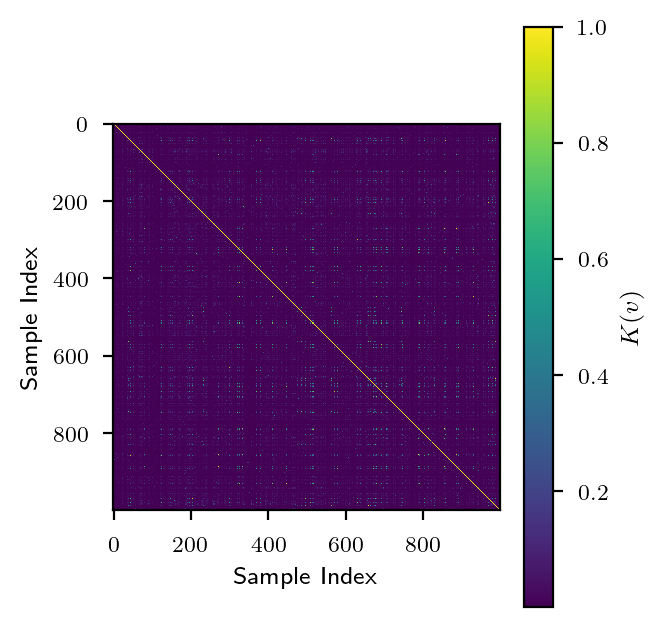

Kernel matrix shape: (1000, 1000)
Min kernel value: 0.000002
Max kernel value: 1.000000


In [7]:
"""
KERNEL MATRIX VISUALISATION
Pick a random 100 samples from the training set and compute the kernel matrix for each of those points
"""

n_random_samples = 1000
random_indices = rng.choice(x_train.shape[0], n_random_samples, replace=False)
x_sample = x_train[random_indices]

# Compute pairwise distances
distances = np.zeros((n_random_samples, n_random_samples))
for i in range(n_random_samples):
    for j in range(n_random_samples):
        distances[i, j] = np.linalg.norm(x_sample[i] - x_sample[j])

normalized_distances = distances / bandwidth

kernel_matrix = np.zeros((n_random_samples, n_random_samples))
for i in range(n_random_samples):
    for j in range(n_random_samples):
        kernel_matrix[i, j] = K_rbf(normalized_distances[i, j], rbf_kernel_hyperparameters['s'])

plt.figure(figsize=set_figure_size(page_width_pt, fraction=0.5, ratio=1.))
plt.imshow(kernel_matrix, cmap='viridis', interpolation='nearest')
plt.colorbar(label='$K(v)$')
plt.xlabel('Sample Index')
plt.ylabel('Sample Index')
plt.tight_layout()
plt.show()

print(f"Kernel matrix shape: {kernel_matrix.shape}")
print(f"Min kernel value: {kernel_matrix.min():.6f}")
print(f"Max kernel value: {kernel_matrix.max():.6f}")


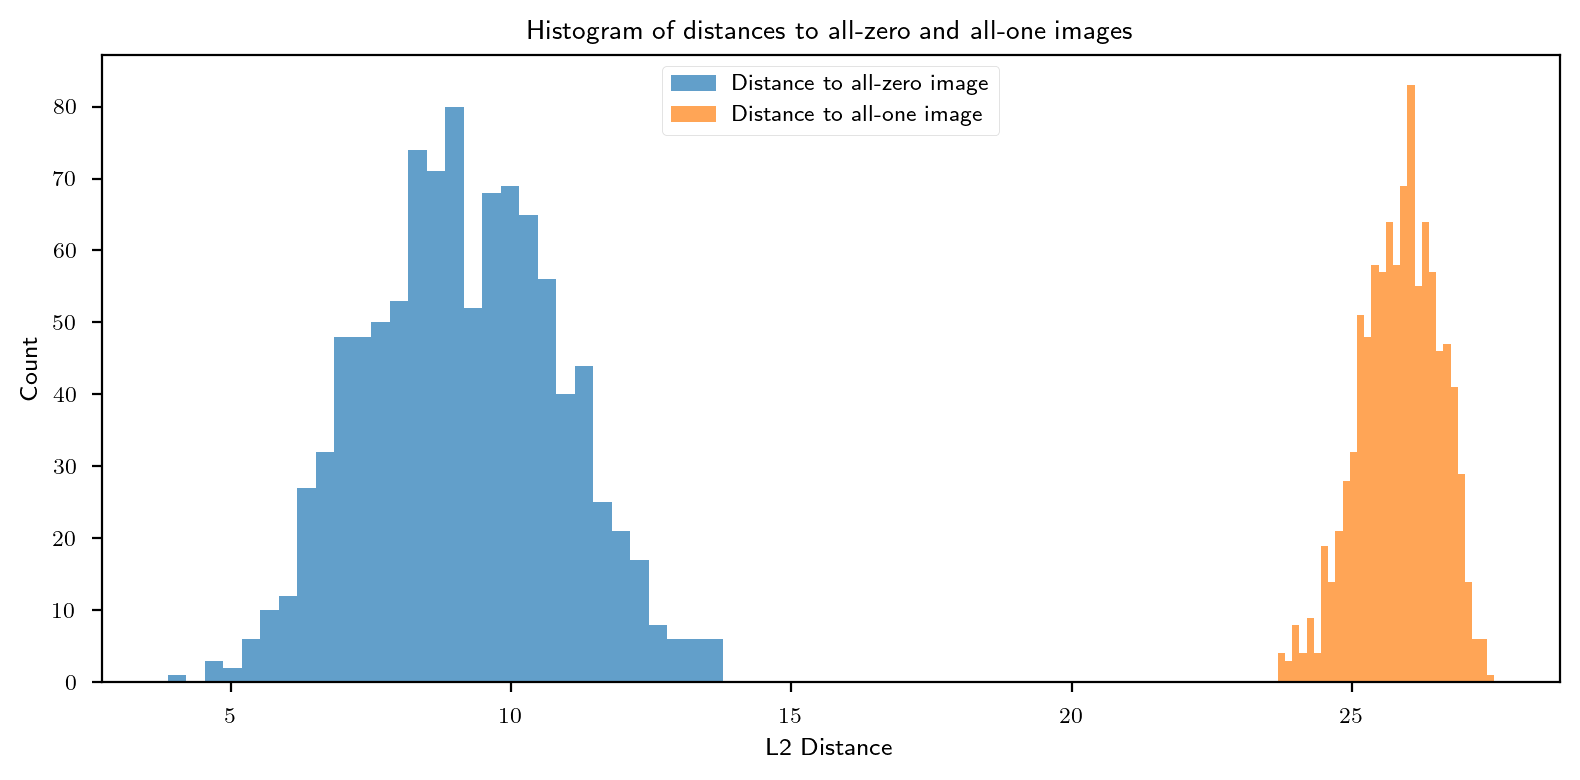

Max distance to zero image: 13.7732
Max distance to one image: 27.5344


In [8]:
# Determine \Phi_{max}: 
# 1. to do this, we create two 28x28 images, one that's all white pixels and the other that's all black pixels
# 2. randomly sample 1000 images from the 


x_zero = np.zeros((784,))
x_one = np.ones((784,))

n_samples = 1000
sample_indices = rng.choice(x_train.shape[0], n_samples, replace=False)
x_sample = x_train[sample_indices]

# Compute distances
dist_zero = np.linalg.norm(x_sample - x_zero, axis=1)
dist_one = np.linalg.norm(x_sample - x_one, axis=1)

# Plot histograms
plt.figure(figsize=(8, 4))
plt.hist(dist_zero, bins=30, alpha=0.7, label='Distance to all-zero image')
plt.hist(dist_one, bins=30, alpha=0.7, label='Distance to all-one image')
plt.xlabel('L2 Distance')
plt.ylabel('Count')
plt.legend()
plt.title('Histogram of distances to all-zero and all-one images')
plt.tight_layout()
plt.show()

print(f"Max distance to zero image: {dist_zero.max():.4f}")
print(f"Max distance to one image: {dist_one.max():.4f}")

phi_max = max(dist_one.max(), dist_zero.max())


In [ ]:
predictions = []
probabilities = []
certainties = []
nontruncation_certainties = []

# nwc = NadarayaWatsonClassifier(bandwidth, 0.02, ck=1e4, kernel=K_rbf, kernel_kwargs=rbf_kernel_hyperparameters)
nwc = NadarayaWatsonClassifier(
    bandwidth=bandwidth, 
    lipschitz_constant=0.03, 
    ck=1.,
    kernel=K_rbf,
    kernel_kwargs=rbf_kernel_hyperparameters
)

for i in range(num_test):
    probs, bounds = nwc.predict(x_test[i], x_train, y_train_one_hot)

    distances = np.linalg.norm(x_train - x_test[i], axis=1)
    weights = K_rbf(distances / bandwidth, **rbf_kernel_hyperparameters)
    e_tail = np.sum(weights[(distances / bandwidth) > 1])
    nontruncation_bound = 0.03 * phi_max * e_tail

    predicted_class = np.argmax(probs)
    predictions.append(predicted_class)
    probabilities.append(probs)
    certainties.append(bounds)
    nontruncation_certainties.append(nontruncation_bound)
    print(f"Test sample {i}: True label = {y_test[i]}, Predicted = {predicted_class}")
    print(f"Maximum probability: {max(probs)}")

print(f"Average bound over {num_test} samples: {np.mean(certainties)}")
print(f"Average nontruncation bound over {num_test} samples: {np.mean(nontruncation_certainties)}")

Test sample 0: True label = 0, Predicted = 0
Maximum probability: 0.663252908964683
Test sample 1: True label = 1, Predicted = 1
Maximum probability: 0.6320296906720531
Test sample 2: True label = 2, Predicted = 1
Maximum probability: 0.3535430428876892
Test sample 3: True label = 3, Predicted = 3
Maximum probability: 0.3507862507229407
Test sample 4: True label = 4, Predicted = 4
Maximum probability: 0.3399380741258369
Test sample 5: True label = 5, Predicted = 5
Maximum probability: 0.28959927608966385
Test sample 6: True label = 6, Predicted = 6
Maximum probability: 0.3381815498193311
Test sample 7: True label = 7, Predicted = 7
Maximum probability: 0.2713685374533266
Test sample 8: True label = 8, Predicted = 1
Maximum probability: 0.1877933678505413
Test sample 9: True label = 9, Predicted = 9
Maximum probability: 0.313685513090721
Average bound over 10 samples: 0.14925187846180074
Average nontruncation bound over 10 samples: 554.8327283345401


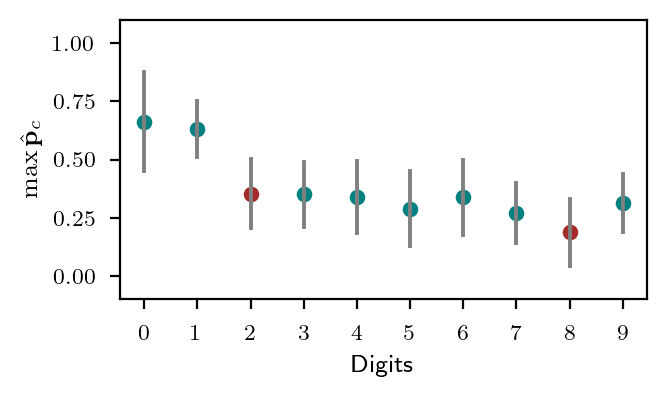

In [10]:
# Visualize maximum probabilities for each digit index with color coding
plt.figure(figsize=set_figure_size(page_width_pt, 0.5))
digit_indices = range(min(10, num_test))
max_probabilities = [max(prob) for prob in probabilities]

# Plot maximum probabilities with confidence intervals
for idx, (prob, bound) in enumerate(zip(max_probabilities, certainties)):
    color = 'teal' if predictions[idx] == y_test[idx] else 'brown'
    plt.plot(idx, prob, 'o', color=color)
    plt.plot([idx, idx], [max(0, prob-bound), min(1, prob+bound)], color='gray')

plt.ylim([-0.1, 1.1])
plt.xticks(digit_indices)
plt.ylabel(r'$\max \hat{\mathbf p}_c$')
plt.xlabel('Digits')
plt.tight_layout()
plt.show()
# plt.grid()
# plt.savefig('results/mnist/predictions.pgf')